In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [9]:
data = np.random.normal(loc=70, scale=10, size=200)

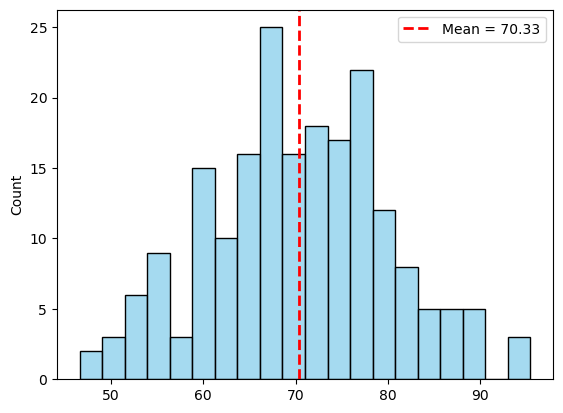

In [36]:

sns.histplot(
    data = data,
    bins = 20,
    color="skyblue",
    # linewidth ='2',
    # linestyle='--'
)
plt.axvline(
    x = data.mean(),
    color='red',
    linestyle='--', 
    linewidth=2,
    label=f"Mean = {data.mean():.2f}"
)
plt.legend()

 # Q2: Penguins — body mass vs flipper length, colored by species

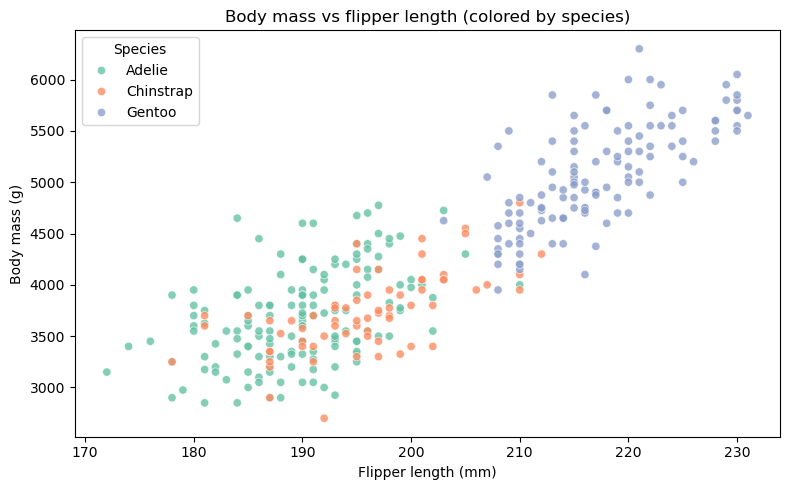

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins")

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    palette="Set2",
    alpha=0.8
)

plt.title("Body mass vs flipper length (colored by species)")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.legend(title="Species")
plt.tight_layout()
plt.show()


 # Q3: Tips — boxplots of total_bill by day with hue = sex, median and outliers# 

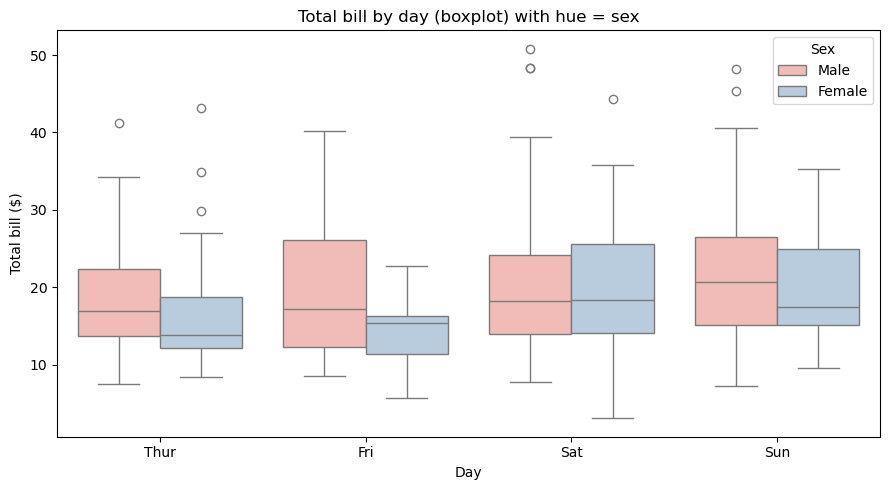

day
Sun     19.63
Sat     18.24
Thur    16.20
Fri     15.38
Name: total_bill, dtype: float64


C:\Users\patil\AppData\Local\Temp\ipykernel_18188\428940424.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_by_day = tips.groupby("day")["total_bill"].median().sort_values(ascending=False)


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

tips = sns.load_dataset("tips")

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="sex",
    palette="Pastel1"
)

plt.title("Total bill by day (boxplot) with hue = sex")
plt.xlabel("Day")
plt.ylabel("Total bill ($)")
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

# Identify highest median day programmatically
median_by_day = tips.groupby("day")["total_bill"].median().sort_values(ascending=False)
print(median_by_day)


# Q4: Tips — scatter of total_bill vs tip with styling and analysis on smokers

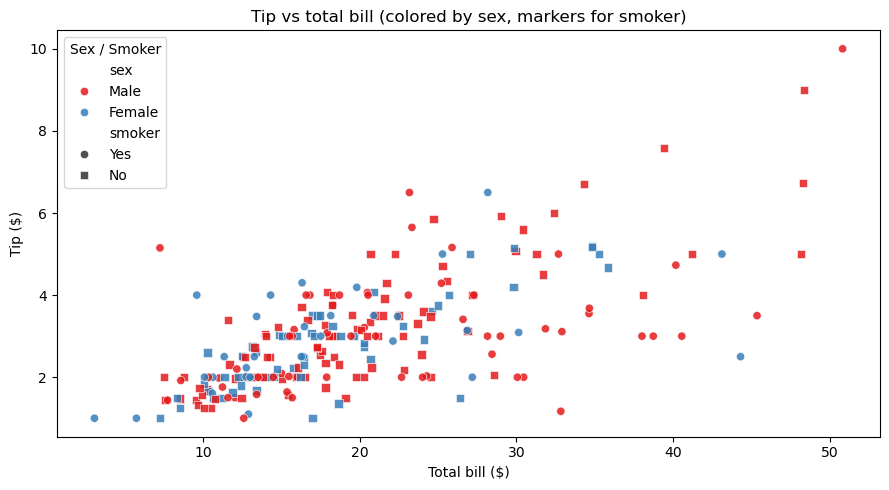

smoker
Yes    0.163196
No     0.159328
Name: tip_pct, dtype: float64


C:\Users\patil\AppData\Local\Temp\ipykernel_18188\3592907869.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pct = tips.assign(tip_pct=tips["tip"] / tips["total_bill"]).groupby("smoker")["tip_pct"].mean()


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="sex",
    style="smoker",       # different markers for smoker/non-smoker
    markers=["o", "s"],
    palette="Set1",
    alpha=0.85
)

plt.title("Tip vs total bill (colored by sex, markers for smoker)")
plt.xlabel("Total bill ($)")
plt.ylabel("Tip ($)")
plt.legend(title="Sex / Smoker")
plt.tight_layout()
plt.show()

# Optional: quick percentage comparison
pct = tips.assign(tip_pct=tips["tip"] / tips["total_bill"]).groupby("smoker")["tip_pct"].mean()
print(pct)


# Q5: Tips — pivot table of average tip (day × time), heatmap, and interpretation

C:\Users\patil\AppData\Local\Temp\ipykernel_18188\3475726008.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = tips.pivot_table(


time     Lunch    Dinner
day                     
Thur  2.767705  3.000000
Fri   2.382857  2.940000
Sat        NaN  2.993103
Sun        NaN  3.255132


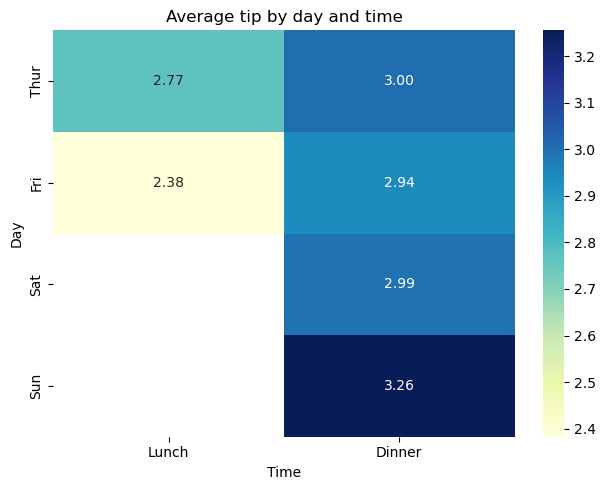

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pivot = tips.pivot_table(
    values="tip",
    index="day",
    columns="time",
    aggfunc="mean"
)

print(pivot)

plt.figure(figsize=(6.5, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average tip by day and time")
plt.xlabel("Time")
plt.ylabel("Day")
plt.tight_layout()
plt.show()
